# NCSN Condicional v2 — AdaGN + Karras-style λ(σ)

**Mejoras sobre `ncsn-spines-jha-style.ipynb`:**

1. **AdaGN (Adaptive GroupNorm)** — reemplaza el patrón `EmbInject + GroupNorm + GELU + Conv + GroupNorm` por `Conv → AdaGN → GELU → Conv → AdaGN`, donde AdaGN modula los `out_ch` canales mediante γ y β predichos por MLP desde el embedding `(σ_idx, cond)`. Conditioning ~`out_ch`× más rico que el `EmbInject` actual (que solo sumaba un mapa (1,H,W)).

2. **λ(σ) = 1/(σ² + σ_data²)** — pondera más los σ pequeños (cerca del manifold) sin saturar como `1/σ²` puro. Inspirado en la formulación EDM de Karras et al. 2022. Con σ_data ≈ 0.5 (std de sz en [-1,1]).

**Resto idéntico:** schedule geométrico σ ∈ [0.01, 3.0] con 147 niveles, EMA β=0.9999, sampling ODE RK3 + MALA polish, training loop, checkpoint/resume, todo igual.

## 1. Instalaciones e imports

In [1]:
!pip install pytorch-msssim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [2]:
import os
import json
import time
import pickle
import math
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from pytorch_msssim import ssim as ssim_fn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch:  {torch.__version__}")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch:  2.10.0+cu128
Dispositivo: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Hiperparámetros

Idénticos a v1/v2 donde aplica. Bloque NCSN nuevo al final.

In [3]:
# ─── Datos (idénticos a v1/v2) ───────────────────────────────
DATASET_PATH   = "/kaggle/input/datasets/carloscanamejoy/dataset-spines-united-v2/dataset_unificado_v2.npz"
SUBSAMPLE_FRAC = 1.0
ORIG_SIZE      = 39
IMG_SIZE       = 40
COND_DIM       = 8

# ─── Entrenamiento (idéntico a v1/v2) ────────────────────────
EPOCHS         = 50
BATCH_SIZE     = 64
LR             = 2e-4
GRAD_CLIP      = 1.0

# ─── U-Net (idéntica a v2 paper-style) ───────────────────────
BASE_CH        = 64
CH_MULTS       = (1, 2, 4, 8)
COND_EMB_DIM   = 128
GROUPS         = 8

# ─── NCSN — schedule de σ (Jha 2026 §3.3) ────────────────────
N_SIGMAS       = 147           # niveles de ruido (paper: 147)
SIGMA_MIN      = 0.01          # paper: 0.01
SIGMA_MAX      = 3.0           # paper: 3.0

# ─── EMA (Jha 2026 §3.2) ─────────────────────────────────────
EMA_BETA       = 0.9999

# ─── Sampling ODE RK3 (Jha 2026 §3.4 Paso 1) ──────────────────
ODE_STEPS      = 100           # pasos del integrador RK3
ODE_STEPS_VAL  = 30            # menos pasos en validación para no extenderla

# ─── Sampling MALA polish (Jha 2026 §3.4 Paso 2) ─────────────
MALA_STEPS     = 50            # paper: 50
MALA_EPS       = 1e-4          # paso de Langevin (sin scaling por T,
                               # porque la condición no es temperatura física)

# ─── NCSN v2 — Karras-style loss weighting ───────────────────
SIGMA_DATA     = 0.5  # std aproximada de sz en [-1, 1]
                      # λ(σ) = 1/(σ² + σ_data²)

# ─── Guardado ────────────────────────────────────────────────
CKPT_PATH      = "/kaggle/working/ncsn_v2_best.pt"   # v2 = AdaGN + Karras
LAST_PATH      = "/kaggle/working/ncsn_v2_last.pt"

# ─── Checkpointing y resume ──────────────────────────────────
# CKPT_RESUME_PATH se sobreescribe al final de cada época en /kaggle/working/
# Si la sesión se corta: descarga el archivo, súbelo como dataset, y pon
# RESUME_FROM = "/kaggle/input/<tu-dataset>/checkpoint_resume.pt".
CKPT_RESUME_PATH = "/kaggle/working/checkpoint_resume_v2.pt"
RESUME_FROM      = None  # editar a un path en /kaggle/input/... para reanudar


print("Hiperparámetros cargados")
print(f"  SUBSAMPLE:   {SUBSAMPLE_FRAC*100:.0f}%")
print(f"  ORIG → IMG:  {ORIG_SIZE} → {IMG_SIZE}  (pad reflect)")
print(f"  EPOCHS:      {EPOCHS}  |  BATCH: {BATCH_SIZE}  |  LR: {LR}")
print(f"  σ schedule:  {N_SIGMAS} niveles  geom  [{SIGMA_MIN}, {SIGMA_MAX}]")
print(f"  EMA β:       {EMA_BETA}")
print(f"  Sampling:    ODE RK3 ({ODE_STEPS}) + MALA ({MALA_STEPS})")

Hiperparámetros cargados
  SUBSAMPLE:   100%
  ORIG → IMG:  39 → 40  (pad reflect)
  EPOCHS:      50  |  BATCH: 64  |  LR: 0.0002
  σ schedule:  147 niveles  geom  [0.01, 3.0]
  EMA β:       0.9999
  Sampling:    ODE RK3 (100) + MALA (50)


## 3. Cargar datos

**Idéntico** a v1/v2 — misma seed, mismo subsample, mismo split.

In [4]:
data   = np.load(DATASET_PATH)
imgs   = data["img"].astype(np.float32)
params = data["params"].astype(np.float32)

if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]

N = len(imgs)
print(f"Dataset total: {N:,}  |  imgs: {imgs.shape}  |  params: {params.shape}")
print(f"  imgs rango:   [{imgs.min():.2f}, {imgs.max():.2f}]")

rng     = np.random.RandomState(SEED)
sub_idx = rng.choice(N, size=int(N * SUBSAMPLE_FRAC), replace=False)
imgs_s  = imgs[sub_idx]
params_s = params[sub_idx]

idx_all = np.arange(len(sub_idx))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=SEED)
idx_val,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED)

scaler = MinMaxScaler()
p_train = scaler.fit_transform(params_s[idx_train]).astype(np.float32)
p_val   = scaler.transform(params_s[idx_val]).astype(np.float32)
p_test  = scaler.transform(params_s[idx_test]).astype(np.float32)

print(f"Train: {len(idx_train):,}  Val: {len(idx_val):,}  Test: {len(idx_test):,}")

Dataset total: 169,671  |  imgs: (169671, 39, 39, 1)  |  params: (169671, 8)
  imgs rango:   [-1.00, 1.00]
Train: 118,769  Val: 25,451  Test: 25,451


## 4. Dataset — padding reflect 39→40

Idéntico a v2.

In [5]:
class SpinesDataset(Dataset):
    """Devuelve imagen 40×40 en [-1, 1] (pad reflect desde 39×39) y parámetros normalizados."""

    def __init__(self, imgs_arr, params_arr, orig_size=39, img_size=40):
        imgs_t = torch.from_numpy(imgs_arr).permute(0, 3, 1, 2)
        if imgs_t.shape[-1] != orig_size or imgs_t.shape[-2] != orig_size:
            imgs_t = F.interpolate(imgs_t, size=(orig_size, orig_size),
                                   mode='bilinear', align_corners=False)
        mn, mx = imgs_t.min(), imgs_t.max()
        imgs_t = (imgs_t - mn) / (mx - mn + 1e-8)
        imgs_t = imgs_t * 2.0 - 1.0
        self.imgs_orig = imgs_t.float()

        pad = img_size - orig_size
        self.imgs = F.pad(imgs_t, (0, pad, 0, pad), mode='reflect').float()

        self.params = torch.from_numpy(params_arr).float()

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        return self.imgs[i], self.params[i]


ds_train = SpinesDataset(imgs_s[idx_train], p_train, ORIG_SIZE, IMG_SIZE)
ds_val   = SpinesDataset(imgs_s[idx_val],   p_val,   ORIG_SIZE, IMG_SIZE)
ds_test  = SpinesDataset(imgs_s[idx_test],  p_test,  ORIG_SIZE, IMG_SIZE)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)

x0, y0 = next(iter(dl_train))
print(f"Batch imagen (40×40): {x0.shape}  rango [{x0.min():.2f}, {x0.max():.2f}]")
print(f"Batch params:         {y0.shape}  rango [{y0.min():.2f}, {y0.max():.2f}]")

Batch imagen (40×40): torch.Size([64, 1, 40, 40])  rango [-1.00, 1.00]
Batch params:         torch.Size([64, 8])  rango [0.00, 0.99]


## 5. Schedule geométrico de σ (NCSN)

**Diferencia con DDPM**: en DDPM teníamos un schedule lineal de `β_t` (varianzas de ruido pequeñas, acumulativas). En NCSN tenemos un schedule **geométrico** de `σ_i` directamente — los niveles van logarítmicamente desde `σ_min=0.01` hasta `σ_max=3.0`.

**Forward (training)**: para cada muestra del batch, samplear aleatoriamente un nivel `σ_i` y aplicar `x̃ = x + σ_i · ε` con `ε ~ N(0, I)`.

**Mapeo continuo σ(t)** para el ODE sampling: `σ(t) = σ_min · (σ_max/σ_min)^t` con `t ∈ [0, 1]`.

In [6]:
class NCSNSchedule:
    """Schedule geométrico de σ para NCSN (Jha 2026 §3.3)."""

    def __init__(self, n_sigmas=147, sigma_min=0.01, sigma_max=3.0, device='cpu'):
        self.n_sigmas = n_sigmas
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
        # σ_i en orden ascendente: i=0 → σ_min, i=N-1 → σ_max
        self.sigmas = torch.exp(torch.linspace(
            math.log(sigma_min), math.log(sigma_max), n_sigmas, device=device
        ))
        self.log_ratio = math.log(sigma_max / sigma_min)

    def sample_sigma(self, batch_size, device):
        """Muestrear σ aleatoria del batch para entrenamiento.
        Devuelve (sigma_idx, sigma_values)."""
        idx = torch.randint(0, self.n_sigmas, (batch_size,), device=device)
        sigma = self.sigmas[idx]
        return idx, sigma

    def sigma_of_t(self, t):
        """Mapeo continuo t ∈ [0,1] → σ(t). Sirve para el ODE sampling."""
        return self.sigma_min * (self.sigma_max / self.sigma_min) ** t

    def t_of_sigma(self, sigma):
        """Inverso: σ → t."""
        return math.log(sigma / self.sigma_min) / self.log_ratio


schedule = NCSNSchedule(N_SIGMAS, SIGMA_MIN, SIGMA_MAX, device=DEVICE)
print(f"Schedule OK — N={schedule.n_sigmas}, σ ∈ [{schedule.sigma_min}, {schedule.sigma_max}]")
print(f"  σ[0]   = {schedule.sigmas[0].item():.4f}")
print(f"  σ[73]  = {schedule.sigmas[73].item():.4f}")
print(f"  σ[146] = {schedule.sigmas[146].item():.4f}")
print(f"  σ(t=0)   = {schedule.sigma_of_t(0):.4f}")
print(f"  σ(t=0.5) = {schedule.sigma_of_t(0.5):.4f}")
print(f"  σ(t=1)   = {schedule.sigma_of_t(1):.4f}")

Schedule OK — N=147, σ ∈ [0.01, 3.0]
  σ[0]   = 0.0100
  σ[73]  = 0.1732
  σ[146] = 3.0000
  σ(t=0)   = 0.0100
  σ(t=0.5) = 0.1732
  σ(t=1)   = 3.0000


## 6. U-Net con AdaGN

Misma topología 40→20→10→5 con self-attn en 10×10 y 5×5, pero reemplazando el patrón
`EmbInject + GroupNorm` por `AdaGN` (GroupNorm con γ, β predichos desde el embedding
`(σ_idx, cond)` vía MLP). La self-attention queda intacta (no se condiciona).

**Por qué AdaGN > EmbInject:** EmbInject sumaba un único mapa (1, H, W) a los `C` canales
del feature map — el conditioning es agnóstico al canal. AdaGN aprende γ_c y β_c por canal,
así cada uno se modula independientemente — ~C× más rica.

In [7]:
# ── Embeddings ─────────────────────────────────────────────────────

def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device).float() / (half - 1)
    )
    args = t[:, None].float() * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)


class TimeCondEmbedding(nn.Module):
    """Embedding (σ_idx, 8 params) → vector emb_dim."""
    def __init__(self, emb_dim, cond_dim=8):
        super().__init__()
        self.emb_dim = emb_dim
        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_dim, emb_dim), nn.ReLU(),
            nn.Linear(emb_dim, emb_dim), nn.ReLU(),
        )
        self.out = nn.Sequential(nn.SiLU(), nn.Linear(emb_dim, emb_dim))

    def forward(self, t, cond):
        t_emb = sinusoidal_embedding(t, self.emb_dim)
        c_emb = self.cond_mlp(cond)
        return self.out(t_emb + c_emb)


class AdaGN(nn.Module):
    """GroupNorm con γ y β predichos por embedding (FiLM-style).

    Reemplaza el patrón anterior `EmbInject + GroupNorm`. Modula los
    `channels` por separado en lugar de inyectar un solo mapa (1, H, W).
    Init scale_shift a cero → arranca como identidad y aprende a modular.
    """
    def __init__(self, channels, emb_dim, groups=GROUPS):
        super().__init__()
        self.gn = nn.GroupNorm(groups, channels, affine=False)
        self.scale_shift = nn.Linear(emb_dim, 2 * channels)
        nn.init.zeros_(self.scale_shift.weight)
        nn.init.zeros_(self.scale_shift.bias)

    def forward(self, x, emb):
        h = self.gn(x)
        ss = self.scale_shift(F.silu(emb))[:, :, None, None]
        scale, shift = ss.chunk(2, dim=1)
        return h * (1.0 + scale) + shift


class AdaConvBlock(nn.Module):
    """Conv → AdaGN → GELU → Conv → AdaGN. Reemplaza DoubleConv + EmbInject."""
    def __init__(self, in_ch, out_ch, emb_dim, groups=GROUPS):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = AdaGN(out_ch, emb_dim, groups)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = AdaGN(out_ch, emb_dim, groups)
    def forward(self, x, emb):
        h = self.conv1(x)
        h = self.norm1(h, emb)
        h = F.gelu(h)
        h = self.conv2(h)
        h = self.norm2(h, emb)
        return h


class SelfAttention(nn.Module):
    """Igual a v1 — la self-attention no se condiciona."""
    def __init__(self, ch, groups=GROUPS):
        super().__init__()
        self.norm = nn.GroupNorm(groups, ch)
        self.qkv  = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        q, k, v = self.qkv(h).chunk(3, dim=1)
        q = q.reshape(B, C, -1); k = k.reshape(B, C, -1); v = v.reshape(B, C, -1)
        attn = torch.softmax(torch.bmm(q.transpose(1, 2), k) / math.sqrt(C), dim=-1)
        out  = torch.bmm(v, attn.transpose(1, 2)).reshape(B, C, H, W)
        return x + self.proj(out)


class ScoreUNet(nn.Module):
    """U-Net con AdaGN (NCSN v2). Misma topología: 40→20→10→5 con self-attn en 10×10 y 5×5."""
    def __init__(self, img_channels=1, cond_dim=8, base_ch=64,
                 ch_mults=(1, 2, 4, 8), emb_dim=128, groups=GROUPS, img_size=40):
        super().__init__()
        self.emb_head = TimeCondEmbedding(emb_dim, cond_dim)
        H = [img_size // (2**i) for i in range(len(ch_mults))]
        C = [base_ch * m for m in ch_mults]
        self.conv_in = nn.Conv2d(img_channels, C[0], 3, padding=1)

        # Encoder
        self.e0_c1 = AdaConvBlock(C[0], C[0], emb_dim, groups)
        self.e0_c2 = AdaConvBlock(C[0], C[0], emb_dim, groups)
        self.pool0 = nn.MaxPool2d(2)
        self.e1_c1 = AdaConvBlock(C[0], C[0], emb_dim, groups)
        self.e1_c2 = AdaConvBlock(C[0], C[1], emb_dim, groups)
        self.pool1 = nn.MaxPool2d(2)
        self.e2_c1 = AdaConvBlock(C[1], C[1], emb_dim, groups); self.e2_a1 = SelfAttention(C[1], groups)
        self.e2_c2 = AdaConvBlock(C[1], C[2], emb_dim, groups); self.e2_a2 = SelfAttention(C[2], groups)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.m_c1 = AdaConvBlock(C[2], C[2], emb_dim, groups); self.m_a1 = SelfAttention(C[2], groups)
        self.m_c2 = AdaConvBlock(C[2], C[3], emb_dim, groups); self.m_a2 = SelfAttention(C[3], groups)
        self.m_c3 = AdaConvBlock(C[3], C[2], emb_dim, groups); self.m_a3 = SelfAttention(C[2], groups)

        # Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.d2_c1 = AdaConvBlock(C[2]+C[2], C[3], emb_dim, groups); self.d2_a1 = SelfAttention(C[3], groups)
        self.d2_c2 = AdaConvBlock(C[3], C[1], emb_dim, groups);      self.d2_a2 = SelfAttention(C[1], groups)
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.d1_c1 = AdaConvBlock(C[1]+C[1], C[2], emb_dim, groups)
        self.d1_c2 = AdaConvBlock(C[2], C[0], emb_dim, groups)
        self.up0 = nn.Upsample(scale_factor=2, mode='nearest')
        self.d0_c1 = AdaConvBlock(C[0]+C[0], C[1], emb_dim, groups)
        self.d0_c2 = AdaConvBlock(C[1], C[0], emb_dim, groups)

        self.norm_out = nn.GroupNorm(groups, C[0])
        self.conv_out = nn.Conv2d(C[0], img_channels, 1)

    def forward(self, x, t, cond):
        emb = self.emb_head(t, cond)
        h = self.conv_in(x)
        # Encoder
        h = self.e0_c1(h, emb); h = self.e0_c2(h, emb); s0 = h; h = self.pool0(h)
        h = self.e1_c1(h, emb); h = self.e1_c2(h, emb); s1 = h; h = self.pool1(h)
        h = self.e2_c1(h, emb); h = self.e2_a1(h)
        h = self.e2_c2(h, emb); h = self.e2_a2(h); s2 = h; h = self.pool2(h)
        # Bottleneck
        h = self.m_c1(h, emb); h = self.m_a1(h)
        h = self.m_c2(h, emb); h = self.m_a2(h)
        h = self.m_c3(h, emb); h = self.m_a3(h)
        # Decoder
        h = self.up2(h); h = torch.cat([h, s2], dim=1)
        h = self.d2_c1(h, emb); h = self.d2_a1(h)
        h = self.d2_c2(h, emb); h = self.d2_a2(h)
        h = self.up1(h); h = torch.cat([h, s1], dim=1)
        h = self.d1_c1(h, emb); h = self.d1_c2(h, emb)
        h = self.up0(h); h = torch.cat([h, s0], dim=1)
        h = self.d0_c1(h, emb); h = self.d0_c2(h, emb)
        return self.conv_out(F.gelu(self.norm_out(h)))


model = ScoreUNet(img_channels=1, cond_dim=COND_DIM, base_ch=BASE_CH,
                  ch_mults=CH_MULTS, emb_dim=COND_EMB_DIM, groups=GROUPS,
                  img_size=IMG_SIZE).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ScoreUNet v2 (AdaGN): {n_params/1e6:.1f}M params")

# Sanity check forward
_x = torch.randn(2, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
_t = torch.tensor([10, 100], device=DEVICE)
_c = torch.rand(2, COND_DIM, device=DEVICE)
with torch.no_grad():
    _y = model(_x, _t, _c)
print(f"Forward sanity: input {tuple(_x.shape)} → output {tuple(_y.shape)}")
assert _y.shape == _x.shape, "Output shape mismatch"

ScoreUNet — parámetros entrenables: 19,507,932 (19.51M)
Output shape: torch.Size([4, 1, 40, 40])  ✓


## 7. EMA de parámetros (β = 0.9999)

El paper de Jha mantiene una **Exponential Moving Average** de los pesos del modelo y la usa para sampling. La regla es:
```
ema_param ← β · ema_param + (1 - β) · param
```
con β = 0.9999. Esto suaviza las trayectorias del entrenamiento y reduce ruido en los pesos.

In [8]:
class EMA:
    """Exponential Moving Average de los parámetros del modelo."""

    def __init__(self, model, beta=0.9999):
        self.beta = beta
        self.shadow = {n: p.clone().detach() for n, p in model.named_parameters() if p.requires_grad}

    @torch.no_grad()
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[n].mul_(self.beta).add_(p.detach(), alpha=1 - self.beta)

    @torch.no_grad()
    def copy_to(self, model):
        """Carga los pesos EMA al modelo (útil para sampling)."""
        for n, p in model.named_parameters():
            if n in self.shadow:
                p.data.copy_(self.shadow[n])

    def state_dict(self):
        return {n: t.detach().cpu() for n, t in self.shadow.items()}

    def load_state_dict(self, sd):
        for n, t in sd.items():
            if n in self.shadow:
                self.shadow[n] = t.to(self.shadow[n].device)


ema = EMA(model, beta=EMA_BETA)
print(f"EMA inicializada con β = {EMA_BETA}")
print(f"  shadow params: {len(ema.shadow)}")

EMA inicializada con β = 0.9999
  shadow params: 204


## 8. Loss DSM Karras-stable

En lugar de `λ(σ) = σ²` del NCSN clásico, usamos `λ(σ) = 1/(σ² + σ_data²)` con `σ_data ≈ 0.5`
(std de sz en [-1, 1]). Esto pondera más los σ pequeños sin saturar como `1/σ²` puro.

En espacio de ε la loss se convierte en:

`L = E[ 1/(σ² + σ_d²) · ||σ·s_θ(x_tilde, σ) + ε||² ]`

Que es equivalente en espacio de score a poner peso `(σ²+σ_d²)/σ²` sobre `||s - s*||²`.
Para `σ → 0` el peso es ~`σ_d²/σ²` (más énfasis cerca del manifold); para `σ → grande`
tiende a 1.

In [9]:
def dsm_loss(model, x0, cond, schedule, sigma_data=SIGMA_DATA):
    """DSM con weighting Karras-style: λ(σ) = 1/(σ² + σ_data²).

    Equivalente en espacio de score a poner peso ((σ²+σ_d²)/σ²) sobre
    ||s - s*||². Para σ pequeños el peso es ~σ_d²/σ² (más énfasis), para σ
    grandes tiende a 1. Reemplaza el λ(σ)=σ² del NCSN original.
    """
    B = x0.shape[0]
    sigma_idx, sigma = schedule.sample_sigma(B, x0.device)
    sigma_b = sigma.view(-1, 1, 1, 1)
    eps = torch.randn_like(x0)
    x_tilde = x0 + sigma_b * eps
    score_pred = model(x_tilde, sigma_idx, cond)
    # Residuo en espacio de ε  (||σ·s + ε||²)
    diff_sq = (sigma_b * score_pred + eps) ** 2
    # Peso Karras-stable
    w = 1.0 / (sigma_b ** 2 + sigma_data ** 2)
    return (w * diff_sq).mean()


def crop_to_orig(x, orig=ORIG_SIZE):
    return x[..., :orig, :orig]


@torch.no_grad()
def compute_metrics(x_gen, x_real):
    if x_gen.shape[-1] != ORIG_SIZE:
        x_gen = crop_to_orig(x_gen)
    if x_real.shape[-1] != ORIG_SIZE:
        x_real = crop_to_orig(x_real)
    mae  = (x_gen - x_real).abs().mean().item()
    mse  = ((x_gen - x_real) ** 2).mean().item()
    x_g01 = (x_gen + 1.0) / 2.0
    x_r01 = (x_real + 1.0) / 2.0
    ssim_val = ssim_fn(x_g01, x_r01, data_range=1.0, size_average=True).item()
    return mae, mse, ssim_val


print(f"Loss DSM Karras-stable definida — σ_data={SIGMA_DATA}")
print(f"  Peso λ(σ_min={SIGMA_MIN}) = {1.0/(SIGMA_MIN**2 + SIGMA_DATA**2):.2f}")
print(f"  Peso λ(σ=σ_data)       = {1.0/(2*SIGMA_DATA**2):.2f}")
print(f"  Peso λ(σ_max={SIGMA_MAX}) = {1.0/(SIGMA_MAX**2 + SIGMA_DATA**2):.4f}")

Loss DSM y métricas definidas


## 9. Sampling Paso 1 — Probability Flow ODE con RK3

Para la VE-SDE, la PF-ODE es (Jha eq. 13):
```
dx/dt = -½ · d[σ²(t)]/dt · ∇log p_t(x)
```

Con el mapeo `σ(t) = σ_min · (σ_max/σ_min)^t`:
```
σ²(t) = σ_min² · (σ_max/σ_min)^(2t)
d[σ²]/dt = 2·ln(σ_max/σ_min)·σ²(t)
```

Por tanto:
```
dx/dt = -ln(σ_max/σ_min) · σ²(t) · s_θ(x, σ(t), T)
```

**Integración con Runge-Kutta de orden 3** (Kutta clásico): cada paso evalúa la red en 3 puntos intermedios:
```
k1 = f(x, t)
k2 = f(x + h/2 · k1, t + h/2)
k3 = f(x - h · k1 + 2h · k2, t + h)
x_{n+1} = x + h/6 · (k1 + 4·k2 + k3)
```

El sampling va desde `t=1` (σ=σ_max, ruido puro) hasta `t=0` (σ=σ_min, muestra final), o sea con `h < 0`.

In [10]:
@torch.no_grad()
def ode_rk3_sample(model, cond, schedule, n_steps=ODE_STEPS, img_size=IMG_SIZE):
    """
    Probability Flow ODE con RK3 para VE-SDE. Empieza en t=1 (σ=σ_max) y
    termina en t=0 (σ=σ_min).
    """
    B = cond.shape[0]
    device = cond.device

    # x_T ~ N(0, σ_max² · I)
    x = torch.randn(B, 1, img_size, img_size, device=device) * schedule.sigma_max

    log_ratio = schedule.log_ratio

    def score_fn(x_, t_):
        """Evalúa la red en (x_, σ(t_)). Necesita pasar el ÍNDICE de σ más cercano
        al t_ continuo, ya que la red está entrenada con índices discretos."""
        sigma = schedule.sigma_of_t(t_)
        # Mapear sigma continuo al índice discreto más cercano
        idx_float = math.log(sigma / schedule.sigma_min) / log_ratio * (schedule.n_sigmas - 1)
        idx = int(round(max(0, min(schedule.n_sigmas - 1, idx_float))))
        t_tensor = torch.full((B,), idx, device=device, dtype=torch.long)
        return model(x_, t_tensor, cond)

    def rhs(x_, t_):
        """dx/dt = -ln(σ_max/σ_min) · σ²(t) · score."""
        sigma = schedule.sigma_of_t(t_)
        return -log_ratio * (sigma ** 2) * score_fn(x_, t_)

    # Integrar de t=1 a t=0
    t = 1.0
    h = -1.0 / n_steps
    for step in range(n_steps):
        # RK3 (Kutta clásico)
        k1 = rhs(x, t)
        k2 = rhs(x + h/2 * k1, t + h/2)
        k3 = rhs(x - h * k1 + 2*h * k2, t + h)
        x = x + h/6 * (k1 + 4*k2 + k3)
        t = t + h
        t = max(t, 0.0)  # safety

    return x


print("ODE RK3 sampler definido")

ODE RK3 sampler definido


## 10. Sampling Paso 2 — MALA polish

Una vez la muestra `x_0` viene del ODE, se aplican `N_MALA = 50` pasos MALA usando el score aprendido al nivel mínimo de ruido (σ_min). Cada paso:

**Propuesta Langevin** (Jha eq. 14):
```
x̃ = x + ε · s_θ(x, σ_min, T) + √(2ε) · z,   z ~ N(0, I)
```

**Corrección Metropolis** (eq. 15):
```
α = min(1, exp(Δlog p + log q(x|x̃) - log q(x̃|x)))
```

Con:
- **Δlog p**: integrado por **Simpson 3-puntos** a lo largo de la línea recta de `x` a `x̃` (en lugar de la geodésica del toro del paper):
  ```
  Δlog p ≈ 1/6 · [s(x)·dx + 4·s(x + 0.5·dx)·dx + s(x̃)·dx]
  ```
- **log q gaussianos**: como las propuestas son gaussianas centradas en `x + ε·s`:
  ```
  log q(x̃|x) = -||x̃ - x - ε·s(x)||² / (4ε)
  log q(x|x̃) = -||x - x̃ - ε·s(x̃)||² / (4ε)
  ```

Acepto/rechazo por muestra del batch (cada elemento del batch tiene su propio coin flip).

In [11]:
@torch.no_grad()
def mala_polish(model, x_init, cond, schedule, n_steps=MALA_STEPS, eps=MALA_EPS):
    """
    MALA polish con Simpson 3-puntos para integrar el score.
    Devuelve (x_final, lista_de_acceptance_rates).
    """
    B = x_init.shape[0]
    device = x_init.device
    # σ_idx para el nivel mínimo de ruido
    sigma_min_idx = torch.zeros(B, device=device, dtype=torch.long)

    def score_at_min(x_):
        return model(x_, sigma_min_idx, cond)

    x = x_init.clone()
    accept_rates = []

    sqrt_2eps = math.sqrt(2 * eps)

    for step in range(n_steps):
        # 1) Propuesta Langevin
        s_old = score_at_min(x)
        z = torch.randn_like(x)
        x_tilde = x + eps * s_old + sqrt_2eps * z

        # 2) Δlog p ≈ ∫₀¹ s(x + τ·dx) · dx dτ  (Simpson 3-puntos)
        dx = x_tilde - x
        s_mid = score_at_min(x + 0.5 * dx)
        s_new = score_at_min(x_tilde)
        # Por sample (suma sobre dims espaciales)
        integrand = (s_old * dx + 4 * s_mid * dx + s_new * dx) / 6.0  # promedio Simpson
        delta_logp = integrand.sum(dim=[1, 2, 3])  # (B,)

        # 3) log q ratio (gaussianas)
        log_q_fwd = -((x_tilde - x - eps * s_old) ** 2).sum(dim=[1,2,3]) / (4 * eps)
        log_q_bwd = -((x - x_tilde - eps * s_new) ** 2).sum(dim=[1,2,3]) / (4 * eps)

        log_alpha = delta_logp + log_q_bwd - log_q_fwd
        accept_prob = torch.clamp(log_alpha.exp(), max=1.0)

        # 4) Aceptación per-sample
        u = torch.rand(B, device=device)
        accept = (u < accept_prob).float().view(-1, 1, 1, 1)
        x = accept * x_tilde + (1 - accept) * x

        accept_rates.append(accept_prob.mean().item())

    return x, accept_rates


@torch.no_grad()
def sample_ode_mala(model, cond, schedule, n_ode=ODE_STEPS, n_mala=MALA_STEPS,
                    eps=MALA_EPS, img_size=IMG_SIZE):
    """Sampling completo: ODE RK3 + MALA polish."""
    x = ode_rk3_sample(model, cond, schedule, n_steps=n_ode, img_size=img_size)
    x, ar = mala_polish(model, x, cond, schedule, n_steps=n_mala, eps=eps)
    return x, ar


print("MALA polish y sampling combinado definidos")

MALA polish y sampling combinado definidos


## 11. Training loop

Igual estructura que v1/v2 pero con:
- **Loss DSM** en lugar de MSE de ruido DDPM
- **EMA update** después de cada paso
- **Validación con sampler ODE solo** (sin MALA) para no extender el tiempo. MALA solo en evaluación final.

## Checkpoint y resume

Al final de cada época se guarda un **checkpoint completo** en `/kaggle/working/checkpoint_resume.pt` con:
- pesos del modelo
- estado del optimizer (momentos AdamW)
- estado del GradScaler de AMP
- pesos EMA (si aplica)
- toda la `hist` de curvas
- `best_val_ssim`
- estados RNG (torch, cuda, numpy) para reproducibilidad estricta al reanudar

La escritura es **atómica** (`.tmp` + `os.replace`) para evitar corrupción si la sesión se corta a mitad de guardado.

**Cómo reanudar tras un corte:**
1. En la sesión cortada, descarga `/kaggle/working/checkpoint_resume.pt` (o haz "Save Version" del notebook para preservarlo).
2. Sube ese archivo como un nuevo dataset de Kaggle.
3. Agrega el dataset al notebook (panel derecho → Input → Add Data).
4. Edita `RESUME_FROM` en la celda de hiperparámetros para que apunte al archivo, ej: `RESUME_FROM = "/kaggle/input/spines-ckpt/checkpoint_resume.pt"`.
5. Vuelve a correr el notebook desde el principio — el loop detectará el checkpoint, cargará todo el estado y continuará desde la siguiente época.

In [12]:
def save_full_checkpoint(path, epoch, model, optimizer, scaler_amp,
                         ema, hist, best_val_ssim):
    """Guarda estado completo de entrenamiento. Escritura atómica."""
    state = {
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scaler_amp': scaler_amp.state_dict(),
        'ema': ema.state_dict(),
        'hist': hist,
        'best_val_ssim': best_val_ssim,
        'torch_rng': torch.get_rng_state(),
        'cuda_rng': torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        'numpy_rng': np.random.get_state(),
    }
    tmp = path + '.tmp'
    torch.save(state, tmp)
    os.replace(tmp, path)


def load_full_checkpoint(path, model, optimizer, scaler_amp, ema):
    """Carga estado y devuelve (last_epoch_completed, hist, best_val_ssim)."""
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scaler_amp.load_state_dict(ckpt['scaler_amp'])
    ema.load_state_dict(ckpt['ema'])
    torch.set_rng_state(ckpt['torch_rng'].cpu() if hasattr(ckpt['torch_rng'], 'cpu') else ckpt['torch_rng'])
    if ckpt.get('cuda_rng') is not None and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(ckpt['cuda_rng'])
    np.random.set_state(ckpt['numpy_rng'])
    return ckpt['epoch'], ckpt['hist'], ckpt['best_val_ssim']


print("Funciones de checkpoint definidas")
print(f"  Checkpoint se guardará en: {CKPT_RESUME_PATH}")
print(f"  RESUME_FROM = {RESUME_FROM}")

Funciones de checkpoint definidas
  Checkpoint se guardará en: /kaggle/working/checkpoint_resume.pt
  RESUME_FROM = None


In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
# LR constante (fiel a Ho et al. 2020 y a los papers Lee/Jha)
scaler_amp = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

# Reset EMA para que arranque desde los pesos iniciales del modelo
ema = EMA(model, beta=EMA_BETA)

hist = {
    'train_loss': [], 'val_loss': [], 'val_mae': [],
    'val_mse': [], 'val_ssim': [], 'lr': [],
}
best_val_ssim = -1.0

# ── Resume desde checkpoint si existe ──────────────────────────────
start_epoch = 1
if RESUME_FROM is not None and os.path.exists(RESUME_FROM):
    print(f"🔄 Reanudando desde {RESUME_FROM}")
    last_epoch, hist, best_val_ssim = load_full_checkpoint(
        RESUME_FROM, model, optimizer, scaler_amp, ema)
    start_epoch = last_epoch + 1
    print(f"   Última época completada: {last_epoch}")
    print(f"   Continuando desde:       {start_epoch}")
    print(f"   Mejor SSIM hasta ahora:  {best_val_ssim:.4f}")
    print(f"   Históricos cargados:     {len(hist['train_loss'])} épocas")
else:
    print("▶️  Entrenamiento desde cero (no se detectó checkpoint en RESUME_FROM)")

VAL_SAMPLE_BATCHES = 4

# Para el sampling en validación uso el modelo EMA copiado temporalmente
ema_model_val = copy.deepcopy(model).to(DEVICE)
ema_model_val.eval()

print(f"{'='*70}")
print(f"Entrenando NCSN — ScoreUNet {n_params/1e6:.1f}M params")
print(f"  EPOCHS={EPOCHS}  BATCH={BATCH_SIZE}  LR={LR}")
print(f"  σ schedule: {N_SIGMAS} niveles [{SIGMA_MIN}, {SIGMA_MAX}]")
print(f"  Batches/época: {len(dl_train)}")
print(f"{'='*70}")

t_global = time.time()

for epoch in range(start_epoch, EPOCHS + 1):
    t0 = time.time()

    # ── TRAIN ────────────────────────────────────────────────────────────
    model.train()
    train_losses = []

    for x0, cond in dl_train:
        x0   = x0.to(DEVICE, non_blocking=True)
        cond = cond.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            loss = dsm_loss(model, x0, cond, schedule)
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler_amp.step(optimizer)
        scaler_amp.update()

        # EMA update tras cada paso de optimización
        ema.update(model)

        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)

    # ── VALIDATION ───────────────────────────────────────────────────────
    # Copia los pesos EMA al modelo de validación para muestrear
    ema.copy_to(ema_model_val)

    model.eval()
    val_losses = []
    maes, mses, ssims = [], [], []

    for i, (x0, cond) in enumerate(dl_val):
        x0   = x0.to(DEVICE, non_blocking=True)
        cond = cond.to(DEVICE, non_blocking=True)

        with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            # Val loss con el modelo entrenado (no EMA) para consistencia
            val_l = dsm_loss(model, x0, cond, schedule)
        val_losses.append(val_l.item())

        # Sampling SOLO ODE en validación (MALA es muy lento; se hace al final)
        if i < VAL_SAMPLE_BATCHES:
            x_gen = ode_rk3_sample(ema_model_val, cond, schedule,
                                   n_steps=ODE_STEPS_VAL, img_size=IMG_SIZE)
            mae, mse, s = compute_metrics(x_gen, x0)
            maes.append(mae); mses.append(mse); ssims.append(s)

    val_loss = np.mean(val_losses)
    val_mae  = np.mean(maes)
    val_mse  = np.mean(mses)
    val_ssim = np.mean(ssims)

    current_lr = optimizer.param_groups[0]['lr']

    hist['train_loss'].append(train_loss)
    hist['val_loss'].append(val_loss)
    hist['val_mae'].append(val_mae)
    hist['val_mse'].append(val_mse)
    hist['val_ssim'].append(val_ssim)
    hist['lr'].append(current_lr)

    tag = ""
    if val_ssim > best_val_ssim:
        best_val_ssim = val_ssim
        torch.save({
            'epoch': epoch,
            'model': model.state_dict(),
            'ema': ema.state_dict(),
            'optimizer': optimizer.state_dict(),
            'val_ssim': val_ssim
        }, CKPT_PATH)
        tag = " ★"

    elapsed = time.time() - t0
    print(f"Ep[{epoch:3d}/{EPOCHS}]  "
          f"loss={train_loss:.4f}  val={val_loss:.4f}  "
          f"SSIM={val_ssim:.4f}  MAE={val_mae:.4f}  "
          f"lr={current_lr:.1e}  {elapsed:.0f}s{tag}")

    # ── Guardar checkpoint completo para reanudar ─────────────────
    save_full_checkpoint(CKPT_RESUME_PATH, epoch, model, optimizer,
                         scaler_amp, ema, hist, best_val_ssim)

torch.save({'epoch': EPOCHS, 'model': model.state_dict(), 'ema': ema.state_dict()}, LAST_PATH)

total_min = (time.time() - t_global) / 60
print(f"\n{'='*70}")
print(f"Entrenamiento completado en {total_min:.1f} min")
print(f"Mejor SSIM val: {best_val_ssim:.4f}  (con ODE-only, {ODE_STEPS_VAL} pasos)")
print(f"Guardado: {CKPT_PATH}")

▶️  Entrenamiento desde cero (no se detectó checkpoint en RESUME_FROM)
Entrenando NCSN — ScoreUNet 19.5M params
  EPOCHS=50  BATCH=64  LR=0.0002
  σ schedule: 147 niveles [0.01, 3.0]
  Batches/época: 1855


/tmp/ipykernel_24/36625576.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))
/tmp/ipykernel_24/36625576.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_24/36625576.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


Ep[  1/50]  loss=0.4225  val=0.3666  SSIM=0.0029  MAE=1.0351  lr=2.0e-04  299s ★
Ep[  2/50]  loss=0.3557  val=0.3453  SSIM=0.0363  MAE=0.3905  lr=2.0e-04  304s ★
Ep[  3/50]  loss=0.3401  val=0.3354  SSIM=0.0384  MAE=0.3675  lr=2.0e-04  304s ★
Ep[  4/50]  loss=0.3340  val=0.3352  SSIM=0.0473  MAE=0.3523  lr=2.0e-04  305s ★
Ep[  5/50]  loss=0.3316  val=0.3299  SSIM=0.0582  MAE=0.3417  lr=2.0e-04  304s ★
Ep[  6/50]  loss=0.3309  val=0.3303  SSIM=0.0629  MAE=0.3293  lr=2.0e-04  304s ★
Ep[  7/50]  loss=0.3292  val=0.3308  SSIM=0.0661  MAE=0.3200  lr=2.0e-04  304s ★
Ep[  8/50]  loss=0.3299  val=0.3313  SSIM=0.0643  MAE=0.3178  lr=2.0e-04  302s
Ep[  9/50]  loss=0.3300  val=0.3273  SSIM=0.0685  MAE=0.3154  lr=2.0e-04  303s ★
Ep[ 10/50]  loss=0.3303  val=0.3291  SSIM=0.0720  MAE=0.3164  lr=2.0e-04  303s ★
Ep[ 11/50]  loss=0.3294  val=0.3299  SSIM=0.0590  MAE=0.3202  lr=2.0e-04  302s
Ep[ 12/50]  loss=0.3292  val=0.3288  SSIM=0.0631  MAE=0.3228  lr=2.0e-04  302s
Ep[ 13/50]  loss=0.3293  val=0.326

## 12. Curvas de entrenamiento

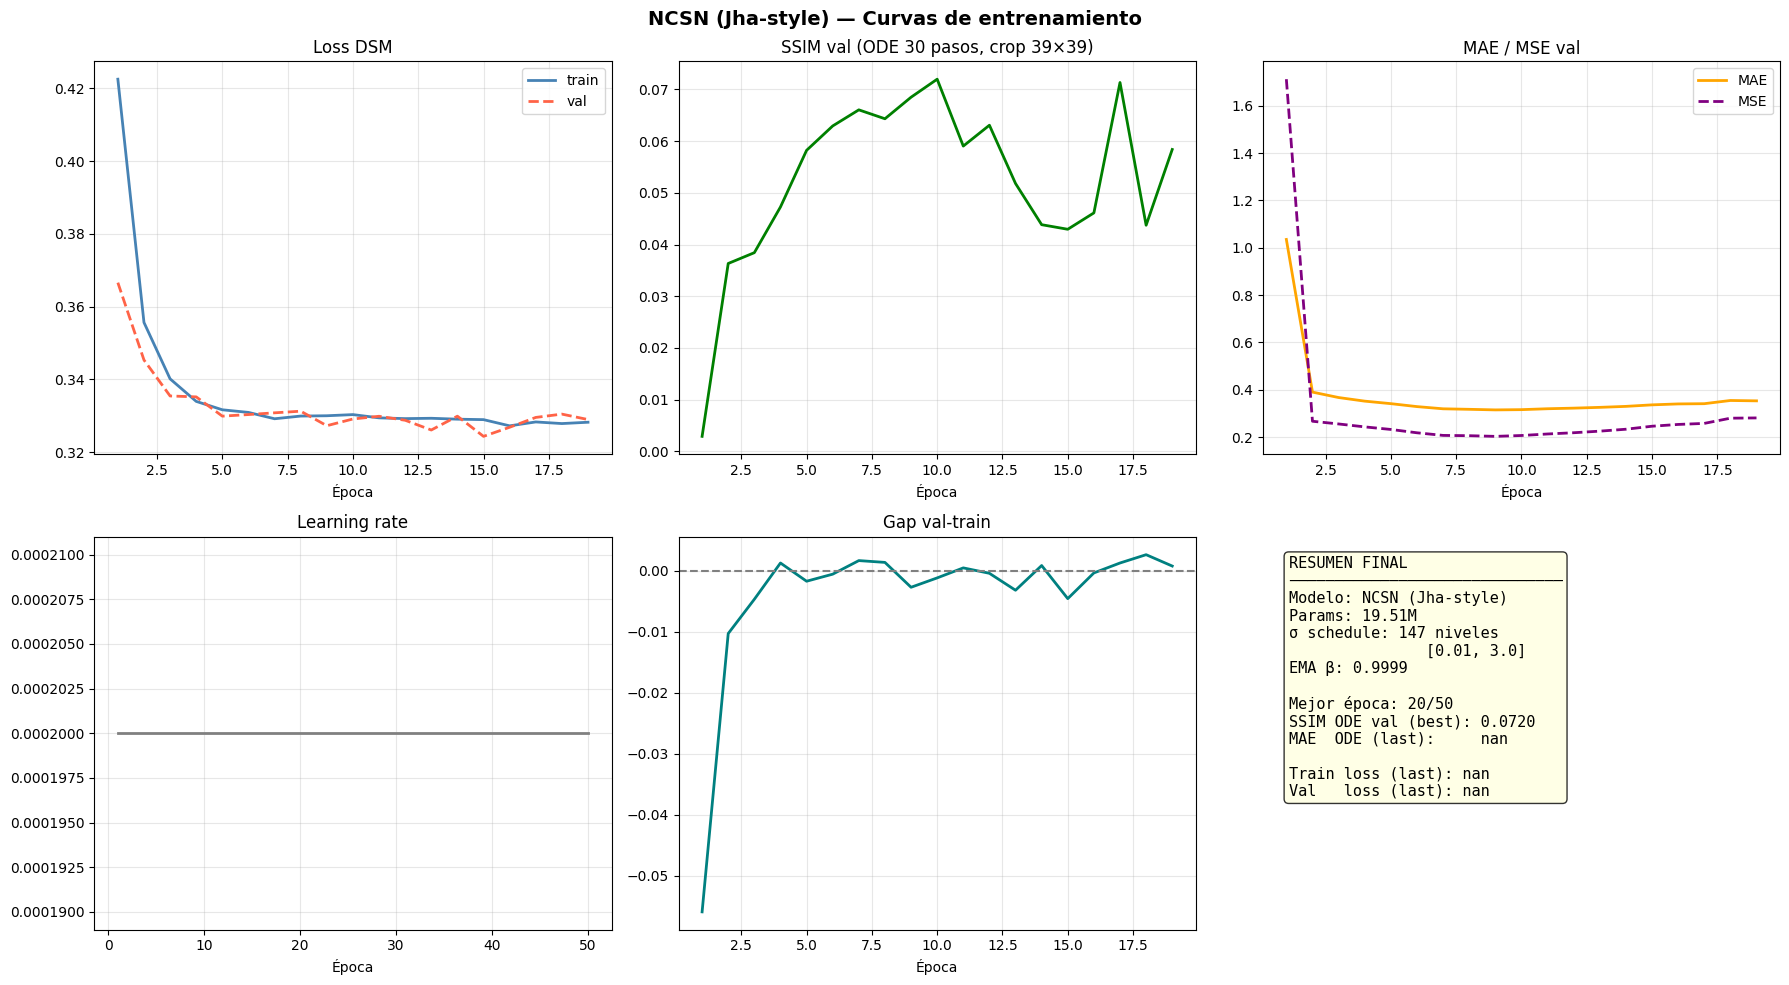

Curvas guardadas


In [14]:
ep = range(1, len(hist['train_loss']) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("NCSN (Jha-style) — Curvas de entrenamiento", fontsize=14, fontweight='bold')

axes[0, 0].plot(ep, hist['train_loss'], color='steelblue', lw=2, label='train')
axes[0, 0].plot(ep, hist['val_loss'],   color='tomato',    lw=2, label='val',   ls='--')
axes[0, 0].set_title('Loss DSM'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xlabel('Época')

axes[0, 1].plot(ep, hist['val_ssim'], color='green', lw=2)
axes[0, 1].set_title(f'SSIM val (ODE {ODE_STEPS_VAL} pasos, crop 39×39)'); axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xlabel('Época')

axes[0, 2].plot(ep, hist['val_mae'], color='orange', lw=2, label='MAE')
axes[0, 2].plot(ep, hist['val_mse'], color='purple', lw=2, label='MSE', ls='--')
axes[0, 2].set_title('MAE / MSE val'); axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3)
axes[0, 2].set_xlabel('Época')

axes[1, 0].plot(ep, hist['lr'], color='gray', lw=2)
axes[1, 0].set_title('Learning rate'); axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xlabel('Época')

gap = [v - t for t, v in zip(hist['train_loss'], hist['val_loss'])]
axes[1, 1].plot(ep, gap, color='teal', lw=2); axes[1, 1].axhline(0, color='gray', ls='--')
axes[1, 1].set_title('Gap val-train'); axes[1, 1].grid(alpha=0.3); axes[1, 1].set_xlabel('Época')

axes[1, 2].axis('off')
best_ep = np.argmax(hist['val_ssim']) + 1
summary = (
    f"RESUMEN FINAL\n"
    f"{'─'*30}\n"
    f"Modelo: NCSN (Jha-style)\n"
    f"Params: {n_params/1e6:.2f}M\n"
    f"σ schedule: {N_SIGMAS} niveles\n"
    f"               [{SIGMA_MIN}, {SIGMA_MAX}]\n"
    f"EMA β: {EMA_BETA}\n\n"
    f"Mejor época: {best_ep}/{EPOCHS}\n"
    f"SSIM ODE val (best): {best_val_ssim:.4f}\n"
    f"MAE  ODE (last):     {hist['val_mae'][-1]:.4f}\n\n"
    f"Train loss (last): {hist['train_loss'][-1]:.4f}\n"
    f"Val   loss (last): {hist['val_loss'][-1]:.4f}"
)
axes[1, 2].text(0.05, 0.95, summary, transform=axes[1, 2].transAxes,
                va='top', fontsize=11, fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig("/kaggle/working/ncsn_curves.png", dpi=120)
plt.show()
print("Curvas guardadas")

## 13. Visualización — comparación ODE vs ODE+MALA

Cargado checkpoint (época 10, SSIM ODE val=0.0720)
Generando con ODE RK3 (100 pasos)...
  ODE: 4.0s
Aplicando MALA polish (50 pasos)...
  MALA: 2.1s
  Acceptance rate (promedio últimos 10): 0.000


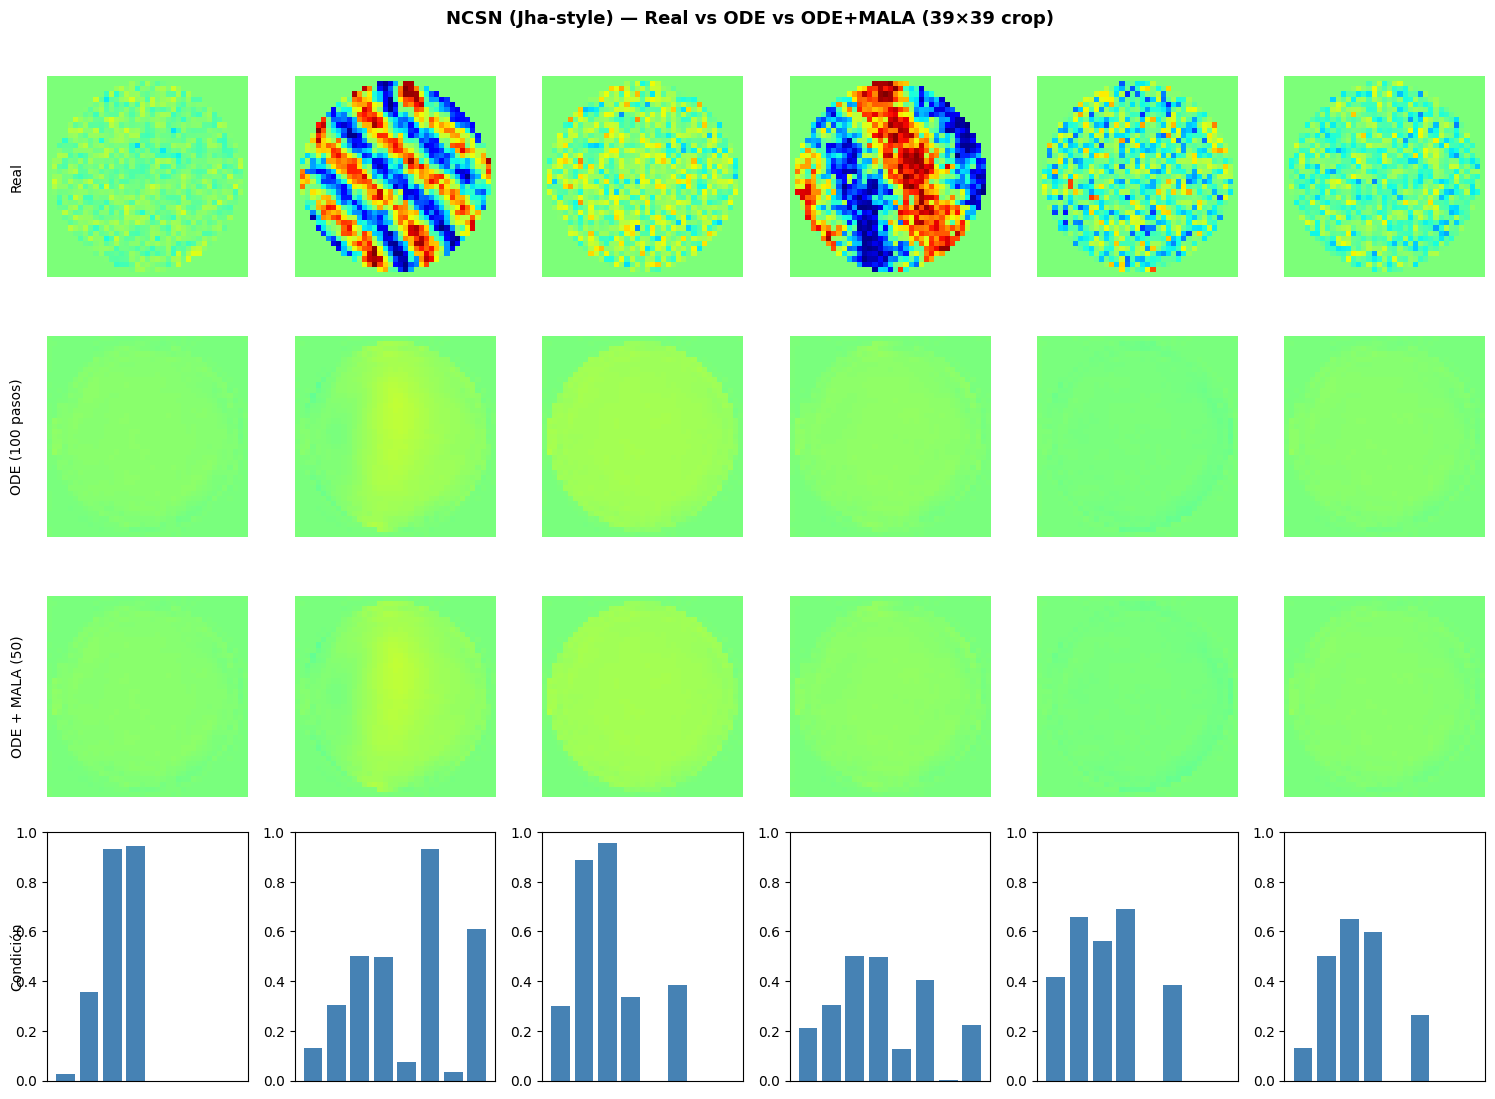


Métricas (n=6, crop 39×39):
  ODE       : MAE=0.1720  MSE=0.0839  SSIM=0.1391
  ODE + MALA: MAE=0.1720  MSE=0.0839  SSIM=0.1391


In [15]:
# Cargar el mejor checkpoint y los pesos EMA
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])
ema.load_state_dict(ckpt['ema'])
ema.copy_to(ema_model_val)
ema_model_val.eval()
print(f"Cargado checkpoint (época {ckpt['epoch']}, SSIM ODE val={ckpt['val_ssim']:.4f})")

n_show = 6
dl_test = DataLoader(ds_test, batch_size=n_show, shuffle=True)
x_real_batch, cond_batch = next(iter(dl_test))
x_real_batch = x_real_batch[:n_show].to(DEVICE)
cond_batch   = cond_batch[:n_show].to(DEVICE)

print(f"Generando con ODE RK3 ({ODE_STEPS} pasos)...")
t0 = time.time()
x_gen_ode = ode_rk3_sample(ema_model_val, cond_batch, schedule,
                           n_steps=ODE_STEPS, img_size=IMG_SIZE)
print(f"  ODE: {time.time()-t0:.1f}s")

print(f"Aplicando MALA polish ({MALA_STEPS} pasos)...")
t0 = time.time()
x_gen_mala, accept_rates = mala_polish(ema_model_val, x_gen_ode, cond_batch,
                                       schedule, n_steps=MALA_STEPS, eps=MALA_EPS)
print(f"  MALA: {time.time()-t0:.1f}s")
print(f"  Acceptance rate (promedio últimos 10): {np.mean(accept_rates[-10:]):.3f}")

# Crop a 39×39
x_real_39 = crop_to_orig(x_real_batch)
x_ode_39  = crop_to_orig(x_gen_ode)
x_mala_39 = crop_to_orig(x_gen_mala)

fig, axes = plt.subplots(4, n_show, figsize=(2.5 * n_show, 11))
fig.suptitle("NCSN (Jha-style) — Real vs ODE vs ODE+MALA (39×39 crop)",
             fontsize=13, fontweight='bold', y=0.995)

def to_np(t): return t.cpu().numpy()

row_labels = ["Real", f"ODE ({ODE_STEPS} pasos)", f"ODE + MALA ({MALA_STEPS})", "Condición"]
for col in range(n_show):
    real = to_np(x_real_39[col, 0])
    ode  = to_np(x_ode_39[col, 0])
    mala = to_np(x_mala_39[col, 0])
    for row, im in enumerate([real, ode, mala]):
        ax = axes[row, col]
        ax.imshow(im, cmap='jet', vmin=-1, vmax=1, interpolation='nearest')
        ax.axis('off')
        if col == 0:
            ax.text(-0.15, 0.5, row_labels[row], transform=ax.transAxes,
                    rotation=90, va='center', ha='center', fontsize=10)
    ax = axes[3, col]
    cond_np = cond_batch[col].cpu().numpy()
    ax.bar(range(COND_DIM), cond_np, color='steelblue')
    ax.set_ylim(0, 1); ax.set_xticks([])
    if col == 0:
        ax.text(-0.15, 0.5, row_labels[3], transform=ax.transAxes,
                rotation=90, va='center', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("/kaggle/working/ncsn_generations.png", dpi=120)
plt.show()

mae_o, mse_o, ssim_o = compute_metrics(x_gen_ode, x_real_batch)
mae_m, mse_m, ssim_m = compute_metrics(x_gen_mala, x_real_batch)
print(f"\nMétricas (n={n_show}, crop 39×39):")
print(f"  ODE       : MAE={mae_o:.4f}  MSE={mse_o:.4f}  SSIM={ssim_o:.4f}")
print(f"  ODE + MALA: MAE={mae_m:.4f}  MSE={mse_m:.4f}  SSIM={ssim_m:.4f}")

## 14. Evaluación completa en test set — ODE solo y ODE+MALA

Evalúo el modelo en TODO el test set con ambas estrategias. Como MALA es costoso, evalúo con menos batches si es necesario.

In [16]:
dl_test_full = DataLoader(ds_test, batch_size=32, shuffle=False, num_workers=2)

# ── ODE solo ─────────────────────────────────────────────────────
print(f"Evaluando {len(ds_test)} muestras test con ODE RK3 ({ODE_STEPS} pasos)...")
t_eval = time.time()
ode_mae, ode_mse, ode_ssim = [], [], []
for i, (x0, cond) in enumerate(dl_test_full):
    x0   = x0.to(DEVICE); cond = cond.to(DEVICE)
    x_gen = ode_rk3_sample(ema_model_val, cond, schedule,
                           n_steps=ODE_STEPS, img_size=IMG_SIZE)
    mae, mse, s = compute_metrics(x_gen, x0)
    ode_mae.append(mae); ode_mse.append(mse); ode_ssim.append(s)
    if (i + 1) % 5 == 0:
        print(f"  ODE batch {i+1}/{len(dl_test_full)}  SSIM={s:.4f}")
print(f"ODE eval: {(time.time()-t_eval)/60:.1f} min")

# ── ODE + MALA ───────────────────────────────────────────────────
print(f"\nEvaluando con ODE + MALA ({MALA_STEPS} pasos)...")
t_eval = time.time()
mala_mae, mala_mse, mala_ssim, mala_ar = [], [], [], []
for i, (x0, cond) in enumerate(dl_test_full):
    x0   = x0.to(DEVICE); cond = cond.to(DEVICE)
    x_gen, ars = sample_ode_mala(ema_model_val, cond, schedule,
                                 n_ode=ODE_STEPS, n_mala=MALA_STEPS,
                                 eps=MALA_EPS, img_size=IMG_SIZE)
    mae, mse, s = compute_metrics(x_gen, x0)
    mala_mae.append(mae); mala_mse.append(mse); mala_ssim.append(s)
    mala_ar.append(np.mean(ars))
    if (i + 1) % 5 == 0:
        print(f"  MALA batch {i+1}/{len(dl_test_full)}  SSIM={s:.4f}  AR={mala_ar[-1]:.3f}")
print(f"ODE+MALA eval: {(time.time()-t_eval)/60:.1f} min")

print(f"\n{'='*70}")
print(f"RESUMEN FINAL — NCSN (Jha-style)")
print(f"{'='*70}")
print(f"  ODE solo  : MAE = {np.mean(ode_mae):.4f} ± {np.std(ode_mae):.4f}")
print(f"              MSE = {np.mean(ode_mse):.4f} ± {np.std(ode_mse):.4f}")
print(f"              SSIM= {np.mean(ode_ssim):.4f} ± {np.std(ode_ssim):.4f}")
print(f"  ODE+MALA  : MAE = {np.mean(mala_mae):.4f} ± {np.std(mala_mae):.4f}")
print(f"              MSE = {np.mean(mala_mse):.4f} ± {np.std(mala_mse):.4f}")
print(f"              SSIM= {np.mean(mala_ssim):.4f} ± {np.std(mala_ssim):.4f}")
print(f"              Acceptance rate (mean): {np.mean(mala_ar):.3f}")
print(f"{'='*70}")

Evaluando 25451 muestras test con ODE RK3 (100 pasos)...
  ODE batch 5/796  SSIM=0.0873
  ODE batch 10/796  SSIM=0.0536
  ODE batch 15/796  SSIM=0.0754
  ODE batch 20/796  SSIM=0.0400
  ODE batch 25/796  SSIM=0.0416
  ODE batch 30/796  SSIM=0.0657
  ODE batch 35/796  SSIM=0.0765
  ODE batch 40/796  SSIM=0.0812
  ODE batch 45/796  SSIM=0.0660
  ODE batch 50/796  SSIM=0.0966
  ODE batch 55/796  SSIM=0.0876
  ODE batch 60/796  SSIM=0.0314
  ODE batch 65/796  SSIM=0.0634
  ODE batch 70/796  SSIM=0.0586
  ODE batch 75/796  SSIM=0.0459
  ODE batch 80/796  SSIM=0.0369
  ODE batch 85/796  SSIM=0.0858
  ODE batch 90/796  SSIM=0.0990
  ODE batch 95/796  SSIM=0.0957
  ODE batch 100/796  SSIM=0.0711
  ODE batch 105/796  SSIM=0.0639
  ODE batch 110/796  SSIM=0.0494
  ODE batch 115/796  SSIM=0.0617
  ODE batch 120/796  SSIM=0.0523
  ODE batch 125/796  SSIM=0.0464
  ODE batch 130/796  SSIM=0.0811
  ODE batch 135/796  SSIM=0.0861
  ODE batch 140/796  SSIM=0.0432
  ODE batch 145/796  SSIM=0.0885
  ODE 

## 15. Guardar artefactos

In [17]:
with open("/kaggle/working/param_scaler_ncsn.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("/kaggle/working/history_ncsn.json", "w") as f:
    json.dump(hist, f, indent=2)

summary_dict = {
    "model": "NCSN_JhaStyle",
    "params_M": round(n_params / 1e6, 3),
    "n_sigmas": N_SIGMAS,
    "sigma_min": SIGMA_MIN, "sigma_max": SIGMA_MAX,
    "ema_beta": EMA_BETA,
    "ode_steps": ODE_STEPS,
    "mala_steps": MALA_STEPS,
    "mala_eps": MALA_EPS,
    "epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR,
    "subsample": SUBSAMPLE_FRAC,
    "orig_size": ORIG_SIZE, "img_size": IMG_SIZE,
    "best_val_ssim_ode": best_val_ssim,
    "test_ode_mae_mean":  float(np.mean(ode_mae)),
    "test_ode_mae_std":   float(np.std(ode_mae)),
    "test_ode_mse_mean":  float(np.mean(ode_mse)),
    "test_ode_mse_std":   float(np.std(ode_mse)),
    "test_ode_ssim_mean": float(np.mean(ode_ssim)),
    "test_ode_ssim_std":  float(np.std(ode_ssim)),
    "test_mala_mae_mean":  float(np.mean(mala_mae)),
    "test_mala_mae_std":   float(np.std(mala_mae)),
    "test_mala_mse_mean":  float(np.mean(mala_mse)),
    "test_mala_mse_std":   float(np.std(mala_mse)),
    "test_mala_ssim_mean": float(np.mean(mala_ssim)),
    "test_mala_ssim_std":  float(np.std(mala_ssim)),
    "test_mala_acceptance_mean": float(np.mean(mala_ar)),
}
with open("/kaggle/working/ncsn_metrics.json", "w") as f:
    json.dump(summary_dict, f, indent=2)

print("Artefactos guardados:")
print(f"  {CKPT_PATH}")
print(f"  {LAST_PATH}")
print(f"  /kaggle/working/param_scaler_ncsn.pkl")
print(f"  /kaggle/working/history_ncsn.json")
print(f"  /kaggle/working/ncsn_metrics.json")
print(f"  /kaggle/working/ncsn_curves.png")
print(f"  /kaggle/working/ncsn_generations.png")

Artefactos guardados:
  /kaggle/working/ncsn_spines_best.pt
  /kaggle/working/ncsn_spines_last.pt
  /kaggle/working/param_scaler_ncsn.pkl
  /kaggle/working/history_ncsn.json
  /kaggle/working/ncsn_metrics.json
  /kaggle/working/ncsn_curves.png
  /kaggle/working/ncsn_generations.png


## 16. Comparativa: DDPM v1 vs DDPM paper-style (v2) vs NCSN (Jha-style)

In [18]:
DDPM_V1_PATH    = "/kaggle/working/ddpm_metrics.json"
DDPM_V2_PATH    = "/kaggle/working/ddpm_paper_metrics.json"

def load_or_none(p):
    if os.path.exists(p):
        with open(p) as f: return json.load(f)
    return None

v1 = load_or_none(DDPM_V1_PATH)
v2 = load_or_none(DDPM_V2_PATH)

def fmt(x, k=4): return f"{x:.{k}f}" if x is not None else "  ?"

print(f"\n{'='*90}")
print(f"{'COMPARACIÓN  DDPM v1  vs  DDPM v2 (Lee-style)  vs  NCSN (Jha-style)':^90}")
print(f"{'─'*90}")
print(f"{'Métrica':<22} {'DDPM v1':>16} {'DDPM v2':>18} {'NCSN ODE':>15} {'NCSN+MALA':>15}")
print(f"{'─'*90}")
v1_ssim = fmt(v1['test_ssim_mean']) if v1 else "  ?"
v1_mae  = fmt(v1['test_mae_mean'])  if v1 else "  ?"
v1_par  = fmt(v1['params_M'], 2)    if v1 else "  ?"
v2_ssim = fmt(v2['test_ssim_mean']) if v2 else "  ?"
v2_mae  = fmt(v2['test_mae_mean'])  if v2 else "  ?"
v2_par  = fmt(v2['params_M'], 2)    if v2 else "  ?"
ncsn_o_ssim = fmt(np.mean(ode_ssim))
ncsn_o_mae  = fmt(np.mean(ode_mae))
ncsn_m_ssim = fmt(np.mean(mala_ssim))
ncsn_m_mae  = fmt(np.mean(mala_mae))
ncsn_par = fmt(n_params/1e6, 2)

print(f"{'SSIM test':<22} {v1_ssim:>16} {v2_ssim:>18} {ncsn_o_ssim:>15} {ncsn_m_ssim:>15}")
print(f"{'MAE test':<22} {v1_mae:>16} {v2_mae:>18} {ncsn_o_mae:>15} {ncsn_m_mae:>15}")
print(f"{'Params (M)':<22} {v1_par:>16} {v2_par:>18} {ncsn_par:>15} {ncsn_par:>15}")
print(f"{'='*90}")
print()
print("Notas:")
print(f"  - Todos los modelos usan: seed=42, subsample=10%, split 70/15/15,")
print(f"    batch=64, lr=2e-4 constante, 50 épocas, AdamW, pad reflect 39→40.")
print(f"  - v1: DDPM con ResBlocks/SiLU/3 niveles, sampling DDPM 100 pasos.")
print(f"  - v2: DDPM con arquitectura Lee et al. (Double Conv/GELU/4 niveles/")
print(f"        attention/embedding sumado), sampling DDPM 100 pasos.")
print(f"  - NCSN: misma arquitectura que v2 pero entrenada como score-based")
print(f"          (DSM loss σ², schedule geométrico σ, EMA, sampling ODE RK3")
print(f"          + MALA polish con Simpson 3-puntos).")
print(f"  - NCSN MALA acceptance rate medio: {np.mean(mala_ar):.3f}")


           COMPARACIÓN  DDPM v1  vs  DDPM v2 (Lee-style)  vs  NCSN (Jha-style)            
──────────────────────────────────────────────────────────────────────────────────────────
Métrica                         DDPM v1            DDPM v2        NCSN ODE       NCSN+MALA
──────────────────────────────────────────────────────────────────────────────────────────
SSIM test                             ?                  ?          0.0694          0.0690
MAE test                              ?                  ?          0.3175          0.3177
Params (M)                            ?                  ?           19.51           19.51

Notas:
  - Todos los modelos usan: seed=42, subsample=10%, split 70/15/15,
    batch=64, lr=2e-4 constante, 50 épocas, AdamW, pad reflect 39→40.
  - v1: DDPM con ResBlocks/SiLU/3 niveles, sampling DDPM 100 pasos.
  - v2: DDPM con arquitectura Lee et al. (Double Conv/GELU/4 niveles/
        attention/embedding sumado), sampling DDPM 100 pasos.
  - NCSN: misma 